# Laboratorio 4: Simulación de eventos discretos (puntos 5.1 a 5.4)
**Santiago Barrera Meza · 160005004**  
Simulación Computacional · Universidad de los Llanos

In [1]:
# Si falta alguna dependencia en Colab/Jupyter, ejecutar en una celda:
# %pip install numpy matplotlib simpy
from pathlib import Path
import csv, json, math, heapq, random, io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import simpy

BASE = Path.cwd()
DATOS = BASE / 'datos'; FIGURAS = BASE / 'figuras'
DATOS.mkdir(exist_ok=True); FIGURAS.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True,
                     'grid.alpha': .22, 'font.size': 10})
print('Versiones:', 'NumPy', np.__version__, 'SimPy', simpy.__version__)

def guardar_csv(nombre, filas):
    if not filas: return
    with (DATOS/nombre).open('w', newline='', encoding='utf-8-sig') as f:
        w=csv.DictWriter(f, fieldnames=list(filas[0])); w.writeheader(); w.writerows(filas)

def resumen(filas, claves, confianza=False):
    salida=[]
    for k in claves:
        x=np.array([f[k] for f in filas], dtype=float)
        media=float(x.mean()); sd=float(x.std(ddof=1))
        r={'medida': k, 'media': media, 'desviacion': sd}
        if confianza:
            assert len(x)==20, 'Este IC usa el cuantil t para 19 grados de libertad.'
            margen=float(2.093024054408263*sd/np.sqrt(len(x)))
            r.update(IC95_inferior=media-margen, IC95_superior=media+margen)
        salida.append(r)
    return salida

def imprimir_tabla(filas):
    claves=list(filas[0])
    print(' | '.join(claves))
    for f in filas:
        print(' | '.join(f'{f[k]:.4f}' if isinstance(f[k],float) else str(f[k]) for k in claves))

Versiones: NumPy 2.5.3 SimPy 4.1.2


## 5.1. Sistema de un servidor
Se interpreta **λ como tasa**, por tanto `exponential(1/λ)`. Escenario A: llegadas de tasa 5,
servicio de tasa 3. B: llegadas de tasa 1 y servicio `max(0, Normal(2,1))`.
En ambos se toma T=40; B conserva el horizonte de A porque no se indica otro.
Estado inicial vacío, servicio FIFO, capacidad de cola ilimitada, primera llegada aleatoria.
Se admiten llegadas hasta T y después se atienden todos los clientes admitidos.

Para el cliente i: inicio = max(llegada, salida anterior), espera = inicio − llegada,
salida = inicio + servicio, permanencia = salida − llegada. El vaciado es max(0, última salida − T).
El máximo cuenta clientes en cola **y en servicio**. En empates se procesa una salida antes
de una llegada; un servicio instantáneo no se cuenta como ocupación de duración positiva.
Las medias son por cliente, no por evento. Se informa una corrida y luego diez réplicas nuevas.

Una corrida por escenario:
escenario | semilla | t_med_sistema | t_med_cola | vaciado | max_clientes | total_clientes
A | 4100 | 15.0261 | 14.7064 | 32.4555 | 107 | 226
B | 4101 | 15.7868 | 13.9930 | 30.4035 | 17 | 38
Diez réplicas por escenario:
Medida | A promedio +/- SD | B promedio +/- SD
t_med_sistema | 13.6048 +/- 3.0418 | 23.6807 +/- 9.1283
t_med_cola | 13.2771 +/- 3.0374 | 21.6890 +/- 9.0914
vaciado | 24.4700 +/- 6.4244 | 43.1648 +/- 15.7418
max_clientes | 77.9000 +/- 18.1381 | 22.8000 +/- 8.0111
total_clientes | 195.0000 +/- 17.3654 | 41.1000 +/- 8.1302


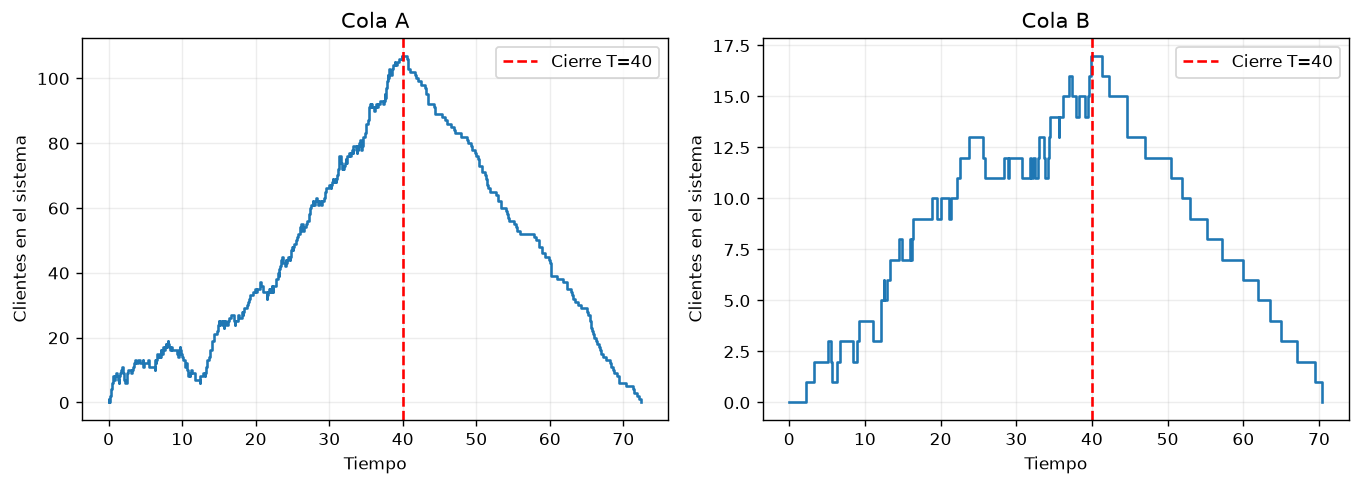

In [2]:
def simular_cola(escenario, semilla, T=40):
    ra, rs = [np.random.default_rng(s) for s in np.random.SeedSequence(semilla).spawn(2)]
    tasa = 5 if escenario=='A' else 1
    reloj=0.; fin=0.; filas=[]; cambios=[]
    while True:
        reloj += ra.exponential(1/tasa)
        if reloj>T: break
        servicio = rs.exponential(1/3) if escenario=='A' else max(0.,rs.normal(2,1))
        inicio=max(reloj,fin); fin=inicio+servicio
        filas.append(dict(cliente=len(filas)+1,llegada=reloj,servicio=servicio,
                          inicio=inicio,salida=fin,cola=inicio-reloj,sistema=fin-reloj))
        if fin>reloj: cambios.extend([(reloj,1),(fin,-1)])
    n=0; maximo=0; ts=[0.]; ns=[0]
    for tiempo,delta in sorted(cambios):
        n+=delta; maximo=max(maximo,n); ts.append(tiempo); ns.append(n)
        assert n>=0
    assert n==0
    met=dict(t_med_sistema=float(np.mean([r['sistema'] for r in filas])) if filas else 0.,
             t_med_cola=float(np.mean([r['cola'] for r in filas])) if filas else 0.,
             vaciado=max(0.,fin-T),max_clientes=maximo,total_clientes=len(filas))
    assert all(r['llegada']<=r['inicio']<=r['salida'] for r in filas)
    assert all(filas[i]['inicio']>=filas[i-1]['salida'] for i in range(1,len(filas)))
    return met,filas,(ts,ns)

claves_cola=['t_med_sistema','t_med_cola','vaciado','max_clientes','total_clientes']
colas={}; resumen_colas={}; corrida_colas=[]
fig,axs=plt.subplots(1,2,figsize=(11,4))
for j,e in enumerate(['A','B']):
    m,f,tr=simular_cola(e,4100+j)
    corrida_colas.append(dict(escenario=e,semilla=4100+j,**m))
    guardar_csv('cola_'+e+'_clientes.csv',f)
    axs[j].step(*tr,where='post'); axs[j].axvline(40,color='red',ls='--',label='Cierre T=40')
    axs[j].set(title='Cola '+e,xlabel='Tiempo',ylabel='Clientes en el sistema'); axs[j].legend()
    filas=[]
    for i in range(10):
        seed=41100+100*j+i
        met, clientes, _=simular_cola(e,seed)
        filas.append(dict(replica=i+1,semilla=seed,**met))
        guardar_csv(f'cola_{e}_replica_{i+1:02d}_clientes.csv',clientes)
    colas[e]=filas; resumen_colas[e]=resumen(filas,claves_cola)
    guardar_csv('cola_'+e+'_replicas.csv',filas)
    guardar_csv('cola_'+e+'_resumen.csv',resumen_colas[e])
fig.tight_layout(); fig.savefig(FIGURAS/'colas.png',dpi=160); plt.show()
print('Una corrida por escenario:'); imprimir_tabla(corrida_colas)
tabla_cola=[]
for a,b in zip(resumen_colas['A'],resumen_colas['B']):
    tabla_cola.append({'Medida':a['medida'],'A promedio +/- SD':f"{a['media']:.4f} +/- {a['desviacion']:.4f}",
                      'B promedio +/- SD':f"{b['media']:.4f} +/- {b['desviacion']:.4f}"})
print('Diez réplicas por escenario:'); imprimir_tabla(tabla_cola)

### Análisis de la cola
A tiene carga ρ=5/3≈1.667. Para B, E[max(0,X)] = 2 Φ(2)+φ(2)≈2.0085 y ρ≈2.0085.
Ambos sistemas están sobrecargados: no hay distribución estacionaria con media finita.
Las medias obtenidas describen **un horizonte finito y su vaciado**, no el largo plazo.
B recibe menos clientes pero requiere mayor servicio por cliente. Una carga mayor no implica
que todas las estadísticas de una corrida sean mayores: también importan las escalas de tiempo
y la variación aleatoria. La desviación usa denominador n−1 y mide variación entre réplicas.

In [3]:
analisis_cola=[]
for a,b in zip(resumen_colas['A'],resumen_colas['B']):
    frase=f"{a['medida']}: media A={a['media']:.3f}; media B={b['media']:.3f}; diferencia B-A={b['media']-a['media']:.3f}."
    analisis_cola.append(frase); print(frase)

t_med_sistema: media A=13.605; media B=23.681; diferencia B-A=10.076.
t_med_cola: media A=13.277; media B=21.689; diferencia B-A=8.412.
vaciado: media A=24.470; media B=43.165; diferencia B-A=18.695.
max_clientes: media A=77.900; media B=22.800; diferencia B-A=-55.100.
total_clientes: media A=195.000; media B=41.100; diferencia B-A=-153.900.


## 5.2. Red de colas
**Variante provisional:** tres servidores FIFO en serie, N1 → N2 → N3 → salida, sin bloqueos,
sin retornos y sin límites de cola. Esta topología es un supuesto y no una reproducción
verificada de la sección 5.5.2 del libro. La ruta es un parámetro de la función.

|Parámetro|A|B|
|---|---:|---:|
|T|300|300|
|Tasa de llegadas|2|3|
|Normal N1 (μ,σ)|(2.1,0.5)|(3,1)|
|Media exponencial N2|2.4|1.5|
|Normal N3 con n3<5|(4.1,2.5)|(4,2)|
|Normal N3 con n3≥5|(3,2)|(2,1.5)|

μ2 se interpreta como **media**, no tasa. Las normales se recortan con max(0,x).
La población n3 incluye al cliente que inicia servicio y a quienes esperan; se consulta al
comenzar su atención. Las llegadas cesan en T y la red se vacía.
`n_med_nj = integral de Nj(t) / H`, con H=max(T, última salida). Se guarda además el promedio
en [0,T] para distinguir la operación del período de vaciado. Los conteos n1,n2,n3 indican
visitas completadas, no la población final (que es cero).

Corrida individual:
escenario | t_med_sistema | n_med_n1 | n_med_n2 | n_med_n3 | vaciado | max_clientes | n1 | n2 | n3 | total_clientes
A | 801.0923 | 151.3251 | 20.5240 | 83.1924 | 1553.2057 | 500 | 590 | 590 | 590 | 590
B | 1243.4633 | 411.7409 | 0.7321 | 5.0149 | 2466.9722 | 832 | 929 | 929 | 929 | 929
20 réplicas, escenario A
medida | media | desviacion | IC95_inferior | IC95_superior
t_med_sistema | 802.3998 | 49.7603 | 779.1113 | 825.6883
n_med_n1 | 157.2392 | 8.2387 | 153.3834 | 161.0950
n_med_n2 | 31.7199 | 11.0459 | 26.5503 | 36.8896
n_med_n3 | 68.4041 | 11.5253 | 63.0101 | 73.7981
vaciado | 1588.9112 | 96.6670 | 1543.6696 | 1634.1527
max_clientes | 512.1500 | 25.2592 | 500.3283 | 523.9717
n1 | 605.9500 | 24.8564 | 594.3169 | 617.5831
n2 | 605.9500 | 24.8564 | 594.3169 | 617.5831
n3 | 605.9500 | 24.8564 | 594.3169 | 617.5831
total_clientes | 605.9500 | 24.8564 | 594.3169 | 617.5831
20 réplicas, escenario B
medida | media | desviacion | IC95_inferior | IC95_superior
t_med_siste

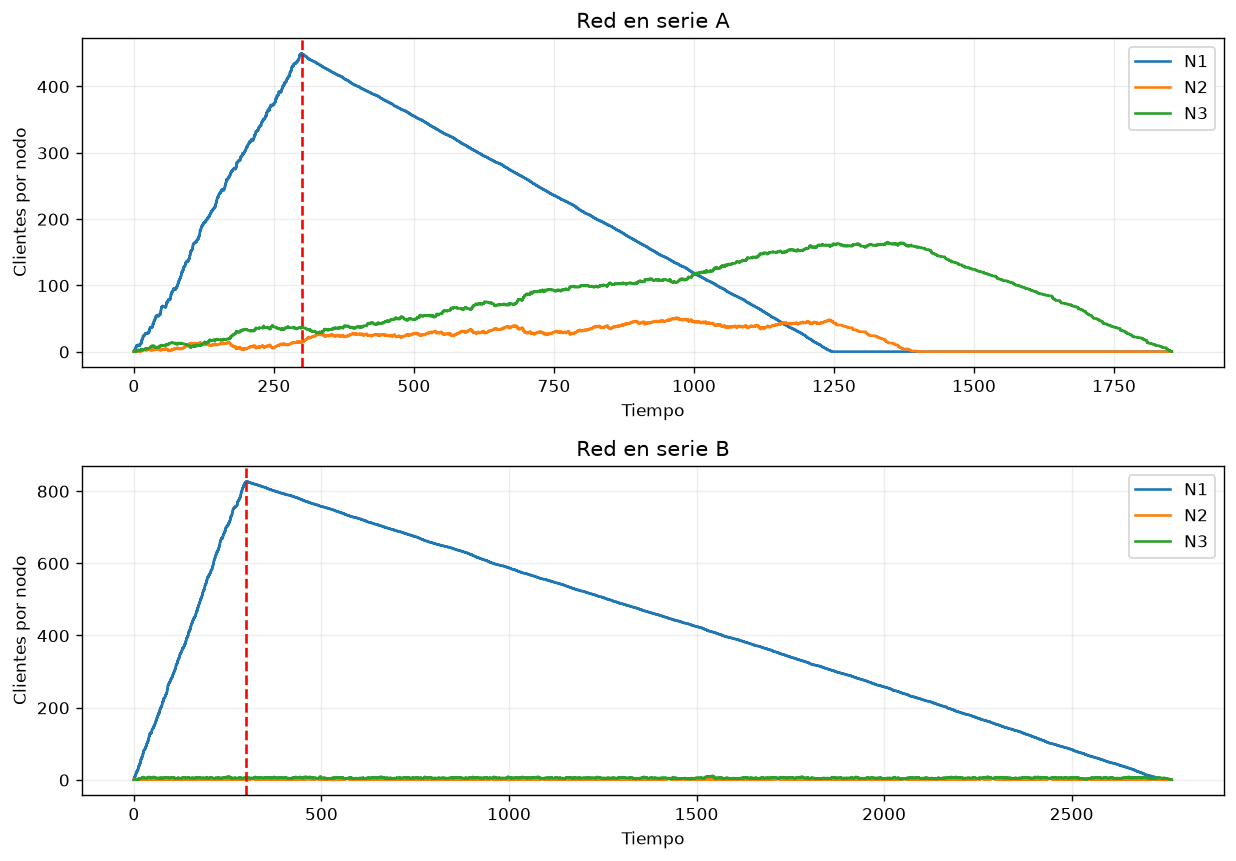

In [4]:
def simular_red(escenario, semilla, T=300, ruta=(0,1,2)):
    rngs=[np.random.default_rng(s) for s in np.random.SeedSequence(semilla).spawn(4)]
    env=simpy.Environment(); recursos=[simpy.Resource(env,capacity=1) for _ in range(3)]
    poblacion=np.zeros(3,dtype=int); area=np.zeros(3); area_T=np.zeros(3)
    ultimo=0.; maximo=0; visitas=[0,0,0]; clientes=[]; pasos=[]; tray=[(0.,0,0,0)]
    p=(2,2.1,.5,2.4,4.1,2.5,3.,2.) if escenario=='A' else (3,3.,1.,1.5,4.,2.,2.,1.5)
    def actualizar(nodo,delta):
        nonlocal ultimo,maximo
        area[:] += poblacion*(env.now-ultimo)
        area_T[:] += poblacion*max(0.,min(env.now,T)-min(ultimo,T))
        ultimo=env.now; poblacion[nodo]+=delta
        assert np.all(poblacion>=0)
        maximo=max(maximo,int(sum(poblacion)))
        tray.append((env.now,*map(int,poblacion)))
    def cliente(i,llegada):
        for nodo in ruta:
            entrada=env.now; actualizar(nodo,1)
            with recursos[nodo].request() as req:
                yield req
                inicio=env.now
                if nodo==0: servicio=max(0.,rngs[1].normal(p[1],p[2]))
                elif nodo==1: servicio=rngs[2].exponential(p[3])
                else:
                    mu,sd=(p[4],p[5]) if poblacion[2]<5 else (p[6],p[7])
                    servicio=max(0.,rngs[3].normal(mu,sd))
                yield env.timeout(servicio)
                pasos.append(dict(cliente=i,nodo=nodo+1,entrada=entrada,inicio=inicio,
                                  salida=env.now,servicio=servicio,espera=inicio-entrada))
                visitas[nodo]+=1; actualizar(nodo,-1)
        clientes.append(dict(cliente=i,llegada=llegada,salida=env.now,sistema=env.now-llegada))
    def llegadas():
        i=0
        while True:
            espera=rngs[0].exponential(1/p[0])
            if env.now+espera>T: break
            yield env.timeout(espera); i+=1; env.process(cliente(i,env.now))
    env.process(llegadas()); env.run()
    H=max(T,env.now)
    media=float(np.mean([x['sistema'] for x in clientes])) if clientes else 0.
    met=dict(t_med_sistema=media, n_med_n1=area[0]/H,n_med_n2=area[1]/H,n_med_n3=area[2]/H,
             vaciado=max(0.,env.now-T),max_clientes=maximo,n1=visitas[0],n2=visitas[1],n3=visitas[2],
             total_clientes=len(clientes),H=H,n_med_n1_T=area_T[0]/T,
             n_med_n2_T=area_T[1]/T,n_med_n3_T=area_T[2]/T)
    assert np.all(poblacion==0)
    assert all(visitas[k]==len(clientes)*ruta.count(k) for k in range(3))
    # Identidad integral de ocupación = suma de permanencias (balance exacto de trayectoria).
    assert np.isclose(sum(area),sum(x['sistema'] for x in clientes))
    return met,clientes,pasos,np.array(tray)

claves_red=['t_med_sistema','n_med_n1','n_med_n2','n_med_n3','vaciado','max_clientes','n1','n2','n3','total_clientes']
redes={}; resumen_redes={}; corrida_redes=[]
fig,axs=plt.subplots(2,1,figsize=(10,7))
for j,e in enumerate(['A','B']):
    m,c,p,tr=simular_red(e,4200+j)
    corrida_redes.append(dict(escenario=e,semilla=4200+j,**m))
    guardar_csv('red_'+e+'_clientes.csv',c); guardar_csv('red_'+e+'_visitas.csv',p)
    for nodo in range(3): axs[j].step(tr[:,0],tr[:,nodo+1],where='post',label=f'N{nodo+1}')
    axs[j].axvline(300,color='red',ls='--'); axs[j].legend()
    axs[j].set(title='Red en serie '+e,xlabel='Tiempo',ylabel='Clientes por nodo')
    filas=[]
    for i in range(20):
        seed=42100+j*100+i
        met,clientes,pasos,_=simular_red(e,seed)
        filas.append(dict(replica=i+1,semilla=seed,**met))
        guardar_csv(f'red_{e}_replica_{i+1:02d}_clientes.csv',clientes)
        guardar_csv(f'red_{e}_replica_{i+1:02d}_visitas.csv',pasos)
    redes[e]=filas; resumen_redes[e]=resumen(filas,claves_red,True)
    guardar_csv('red_'+e+'_replicas.csv',filas)
    guardar_csv('red_'+e+'_resumen.csv',resumen_redes[e])
fig.tight_layout(); fig.savefig(FIGURAS/'redes.png',dpi=160); plt.show()
print('Corrida individual:'); imprimir_tabla([{k:r[k] for k in ['escenario']+claves_red} for r in corrida_redes])
for e in ['A','B']:
    print('20 réplicas, escenario',e); imprimir_tabla(resumen_redes[e])

### Interpretación estadística
Para cada indicador: media = Σxi/20; s = √[Σ(xi−media)²/19].
IC95% de la media = media ± t(0.975,19) s/√20, con t≈2.093.
Es un intervalo aproximado para la **media de réplicas bajo el modelo**, no un rango que
contenga el 95% de clientes ni una probabilidad posterior sobre la media fija. Los 20 ensayos
son independientes por semilla; el tamaño pequeño y las distribuciones sesgadas limitan la
aproximación. Son intervalos marginales: no garantizan cobertura conjunta del 95% para todas
las métricas. La superposición no sustituye una prueba de diferencia entre escenarios.

Con la ruta en serie, todas las visitas n1=n2=n3=total; por ello esos cuatro resúmenes deben
coincidir. La mayor congestión no se deduce solo de μ3: la entrada que recibe N3 está limitada
por sus predecesores. N1 ya presenta sobrecarga (aprox. 4.2 en A y 9 en B), por lo que los
resultados también son de horizonte finito. No se extrapolan a una red con otra topología.

In [5]:
analisis_red=[]
for e in ['A','B']:
    for r in resumen_redes[e]:
        cv=r['desviacion']/r['media'] if r['media'] else 0
        ancho=r['IC95_superior']-r['IC95_inferior']
        frase=f"{e} {r['medida']}: media {r['media']:.3f}, SD {r['desviacion']:.3f}, CV {100*cv:.1f}%, ancho IC {ancho:.3f}."
        analisis_red.append(frase); print(frase)
print('Mayor CV implica mayor variación relativa; menor ancho de IC implica mayor precisión absoluta.')

A t_med_sistema: media 802.400, SD 49.760, CV 6.2%, ancho IC 46.577.
A n_med_n1: media 157.239, SD 8.239, CV 5.2%, ancho IC 7.712.
A n_med_n2: media 31.720, SD 11.046, CV 34.8%, ancho IC 10.339.
A n_med_n3: media 68.404, SD 11.525, CV 16.8%, ancho IC 10.788.
A vaciado: media 1588.911, SD 96.667, CV 6.1%, ancho IC 90.483.
A max_clientes: media 512.150, SD 25.259, CV 4.9%, ancho IC 23.643.
A n1: media 605.950, SD 24.856, CV 4.1%, ancho IC 23.266.
A n2: media 605.950, SD 24.856, CV 4.1%, ancho IC 23.266.
A n3: media 605.950, SD 24.856, CV 4.1%, ancho IC 23.266.
A total_clientes: media 605.950, SD 24.856, CV 4.1%, ancho IC 23.266.
B t_med_sistema: media 1225.136, SD 50.864, CV 4.2%, ancho IC 47.610.
B n_med_n1: media 398.423, SD 15.037, CV 3.8%, ancho IC 14.075.
B n_med_n2: media 0.655, SD 0.047, CV 7.2%, ancho IC 0.044.
B n_med_n3: media 4.947, SD 0.149, CV 3.0%, ancho IC 0.139.
B vaciado: media 2438.221, SD 93.485, CV 3.8%, ancho IC 87.505.
B max_clientes: media 809.050, SD 28.769, CV 3.

## 5.3. Inventario probabilístico
La figura de la guía representa una política (p,P): si I≤p y no hay un pedido pendiente,
ordenar Q=P−I. Se adopta **p como punto de reposición**, aunque el texto lo llama cantidad
a pedir. Valores de la guía: P0=20, P=100, p=20, L=5, h=100, r=150.
El pedido inicial de 80 unidades se realiza en t=0 porque P0=p.

**Supuestos adicionales, no datos del enunciado:** T=100 unidades de tiempo, λ=2 clientes
por unidad de tiempo; demanda entera uniforme entre 1 y 5, costo de almacenamiento c=1 por
unidad y tiempo, costo fijo de pedido K=0; ventas perdidas, atención parcial si falta stock,
sin devolución, stock final sin valor de rescate. Se admite como cliente satisfecho solo a
quien recibió toda su demanda. Entregas y compras se valoran a h por unidad; se contabiliza
la compra al emitir la orden. En t=T se cierra el registro, sin recibir órdenes posteriores.

Ingresos R=r·unidades vendidas; almacenamiento CA=c∫I(t)dt; pedidos CP=Σ(hQ+K).
Beneficio de caja = R−CA−CP−hP0. Descontar P0 evita tratar el stock inicial como gratuito;
se registra el capital final para no confundir este flujo de caja con un beneficio contable.
El porcentaje de inventario en cero es 100·tiempo con I=0/T, no porcentaje de eventos.

medida | valor
beneficio | 14547.4497
clientes_satisfechos_pct | 87.4346
inventario_cero_pct | 10.8346
clientes | 191
satisfechos | 167
demanda_total | 589
unidades_vendidas | 513
stock_final | 74
pedido_pendiente | 0
ingresos | 76950.0000
costo_almacenamiento | 3702.5503
costo_pedidos | 56700.0000
costo_inicial | 2000
capital_final | 7400
Beneficio de caja: 14547.45; satisfacción completa: 87.43%; tiempo sin stock: 10.83%.
La demanda no atendida se pierde. Un cliente parcialmente atendido genera ingreso, pero no cuenta como satisfecho.


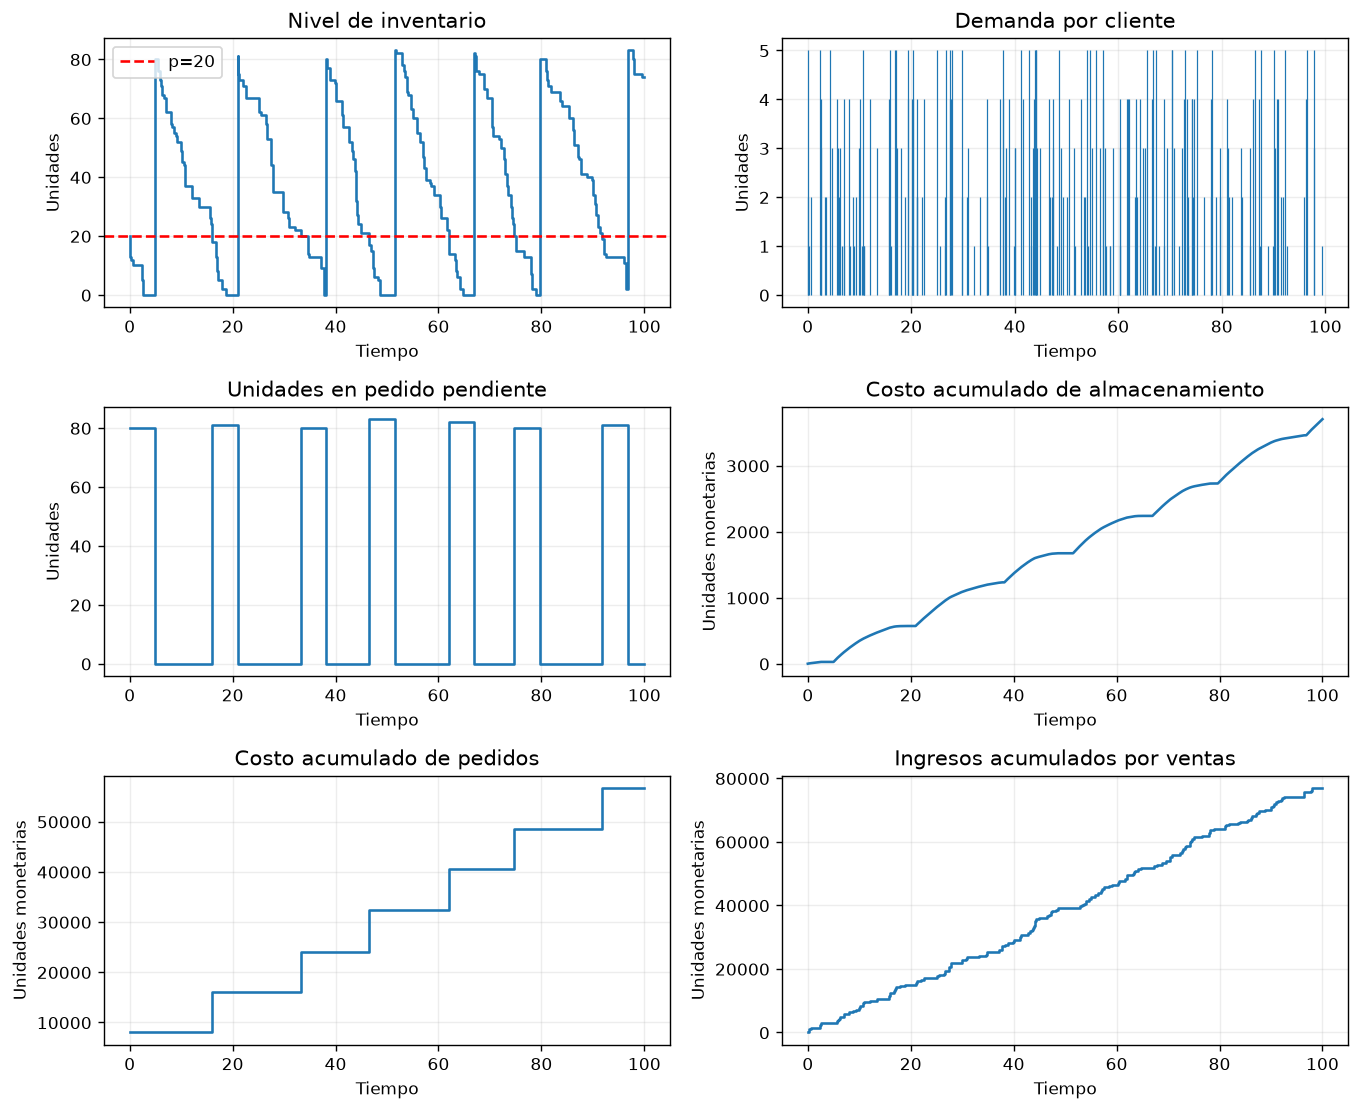

In [6]:
def simular_inventario(semilla=4300,T=100,tasa=2,P0=20,P=100,p=20,L=5,h=100,r=150,c=1,K=0):
    ra,rd=[np.random.default_rng(s) for s in np.random.SeedSequence(semilla).spawn(2)]
    I=P0; pendiente=0; recepcion=math.inf; llegada=ra.exponential(1/tasa)
    t=0.; area=0.; cero=0.; ingresos=0.; compras=0.; vendidos=0; demandados=0
    satisfechos=0; clientes=0; recibidos=0; pedidos=[]; historia=[]
    def ordenar():
        nonlocal pendiente,recepcion,compras
        if I<=p and pendiente==0:
            pendiente=P-I; recepcion=t+L; compras+=h*pendiente+K
            pedidos.append(dict(emision=t,recepcion=recepcion,cantidad=pendiente,costo=h*pendiente+K))
    def registrar(evento,demanda=0):
        historia.append(dict(t=t,evento=evento,inventario=I,demanda=demanda,
                             pendiente=pendiente,almacenamiento=c*area,pedidos=compras,ingresos=ingresos))
    ordenar(); registrar('inicio')
    while t<T:
        siguiente=min(llegada,recepcion,T); dt=siguiente-t
        area+=I*dt; cero+=(I==0)*dt; t=siguiente
        if t==T: registrar('cierre'); break
        if recepcion<=llegada:
            I+=pendiente; recibidos+=pendiente; pendiente=0; recepcion=math.inf
            ordenar(); registrar('recepcion')
        else:
            d=int(rd.integers(1,6)); venta=min(I,d); I-=venta
            clientes+=1; satisfechos+=int(venta==d); vendidos+=venta; demandados+=d; ingresos+=r*venta
            ordenar(); registrar('cliente',d); llegada=t+ra.exponential(1/tasa)
        assert 0<=I<=P and 0<=pendiente<=P
    assert P0+recibidos==vendidos+I
    assert sum(x['cantidad'] for x in pedidos)==recibidos+pendiente
    met=dict(beneficio=ingresos-c*area-compras-h*P0,
             clientes_satisfechos_pct=100*satisfechos/clientes if clientes else 0.,
             inventario_cero_pct=100*cero/T,clientes=clientes,satisfechos=satisfechos,
             demanda_total=demandados,unidades_vendidas=vendidos,stock_final=I,
             pedido_pendiente=pendiente,ingresos=ingresos,costo_almacenamiento=c*area,
             costo_pedidos=compras,costo_inicial=h*P0,capital_final=h*(I+pendiente))
    return met,historia,pedidos

inventario,hist_inv,pedidos_inv=simular_inventario()
guardar_csv('inventario_eventos.csv',hist_inv); guardar_csv('inventario_pedidos.csv',pedidos_inv)
guardar_csv('inventario_resumen.csv',[inventario])
imprimir_tabla([{'medida':k,'valor':v} for k,v in inventario.items()])
fig,axs=plt.subplots(3,2,figsize=(11,9)); tiempos=[x['t'] for x in hist_inv]
for ax,k,titulo in zip(axs.flat,['inventario','demanda','pendiente','almacenamiento','pedidos','ingresos'],
                      ['Nivel de inventario','Demanda por cliente','Unidades en pedido pendiente',
                       'Costo acumulado de almacenamiento','Costo acumulado de pedidos','Ingresos acumulados por ventas']):
    if k=='demanda':
        eventos=[x for x in hist_inv if x['evento']=='cliente']
        ax.vlines([x['t'] for x in eventos],0,[x[k] for x in eventos],lw=.7)
    else: ax.step(tiempos,[x[k] for x in hist_inv],where='post') if k not in ['almacenamiento'] else ax.plot(tiempos,[x[k] for x in hist_inv])
    ax.set(title=titulo,xlabel='Tiempo',ylabel='Unidades' if k in ['inventario','demanda','pendiente'] else 'Unidades monetarias')
axs[0,0].axhline(20,color='red',ls='--',label='p=20'); axs[0,0].legend()
fig.tight_layout(); fig.savefig(FIGURAS/'inventario.png',dpi=160); plt.show()
print(f"Beneficio de caja: {inventario['beneficio']:.2f}; satisfacción completa: {inventario['clientes_satisfechos_pct']:.2f}%; tiempo sin stock: {inventario['inventario_cero_pct']:.2f}%.")
print('La demanda no atendida se pierde. Un cliente parcialmente atendido genera ingreso, pero no cuenta como satisfecho.')

## 5.4. Simulación con SimPy
Se ejecuta una introducción propia a los conceptos de **SimPy in 10 Minutes** y las siete
implementaciones oficiales enlazadas por la guía. Cada ejemplo se conserva en una celda
independiente y usa su propia semilla oficial. El código se atribuye al proyecto SimPy;
no se presenta como creación original. Las salidas completas están en `datos/simpy_*.txt`.
La presentación audiovisual y el notebook de Colab no se verificaron; no se afirma haberlos visto.

### Tutorial paso a paso
1. Crear Environment y registrar procesos con `env.process`.
2. Usar `yield env.timeout` para alternar conducción y estacionamiento.
3. Solicitar un Resource para representar un cargador compartido.
4. Esperar el proceso de carga con `yield env.process`.
5. Interrumpir un proceso con `interrupt`, capturar Interrupt y reanudar una actividad.
6. Ejecutar y leer el reloj en cada transición.

In [7]:
def tutorial_simpy():
    env=simpy.Environment(); cargador=simpy.Resource(env,capacity=1)
    def cargar(nombre):
        print(env.now,nombre,'cargando'); yield env.timeout(4)
    def coche(nombre):
        print(env.now,nombre,'conduce'); yield env.timeout(2)
        with cargador.request() as req:
            print(env.now,nombre,'solicita cargador'); yield req
            yield env.process(cargar(nombre))
        print(env.now,nombre,'sale')
    env.process(coche('A')); env.process(coche('B')); env.run()
    assert env.now==10
    env=simpy.Environment()
    def trabajo():
        try: yield env.timeout(10)
        except simpy.Interrupt:
            print(env.now,'interrupción; comienza tarea de recuperación')
            yield env.timeout(2)
            print(env.now,'recuperación completada')
    def interrumpir(proceso):
        yield env.timeout(3); proceso.interrupt()
    p=env.process(trabajo()); env.process(interrumpir(p)); env.run()
tutorial_simpy()

0 A conduce
0 B conduce
2 A solicita cargador
2 B solicita cargador
2 A cargando
6 A sale
6 B cargando
10 B sale
3 interrupción; comienza tarea de recuperación
5 recuperación completada


### Bank Renege
Un recurso atiende clientes que abandonan cuando vence su paciencia. El evento compuesto solicitud | timeout distingue servicio y abandono.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/bank_renege.html

In [8]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Bank renege example

    Covers:

    - Resources: Resource
    - Condition events

    Scenario:
      A counter with a random service time and customers who renege. Based on the
      program bank08.py from TheBank tutorial of SimPy 2. (KGM)

    """

    import random

    import simpy

    RANDOM_SEED = 42
    NEW_CUSTOMERS = 5  # Total number of customers
    INTERVAL_CUSTOMERS = 10.0  # Generate new customers roughly every x seconds
    MIN_PATIENCE = 1  # Min. customer patience
    MAX_PATIENCE = 3  # Max. customer patience


    def source(env, number, interval, counter):
        """Source generates customers randomly"""
        for i in range(number):
            c = customer(env, f'Customer{i:02d}', counter, time_in_bank=12.0)
            env.process(c)
            t = random.expovariate(1.0 / interval)
            yield env.timeout(t)


    def customer(env, name, counter, time_in_bank):
        """Customer arrives, is served and leaves."""
        arrive = env.now
        print(f'{arrive:7.4f} {name}: Here I am')

        with counter.request() as req:
            patience = random.uniform(MIN_PATIENCE, MAX_PATIENCE)
            # Wait for the counter or abort at the end of our tether
            results = yield req | env.timeout(patience)

            wait = env.now - arrive

            if req in results:
                # We got to the counter
                print(f'{env.now:7.4f} {name}: Waited {wait:6.3f}')

                tib = random.expovariate(1.0 / time_in_bank)
                yield env.timeout(tib)
                print(f'{env.now:7.4f} {name}: Finished')

            else:
                # We reneged
                print(f'{env.now:7.4f} {name}: RENEGED after {wait:6.3f}')


    # Setup and start the simulation
    print('Bank renege')
    random.seed(RANDOM_SEED)
    env = simpy.Environment()

    # Start processes and run
    counter = simpy.Resource(env, capacity=1)
    env.process(source(env, NEW_CUSTOMERS, INTERVAL_CUSTOMERS, counter))
    env.run()

salida = registro.getvalue()
(DATOS/'simpy_bank_renege.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Bank renege
 0.0000 Customer00: Here I am
 0.0000 Customer00: Waited  0.000
 3.8595 Customer00: Finished
10.2006 Customer01: Here I am
10.2006 Customer01: Waited  0.000
12.7265 Customer02: Here I am
13.9003 Customer02: RENEGED after  1.174
23.7507 Customer01: Finished
34.9993 Customer03: Here I am
34.9993 Customer03: Waited  0.000
37.9599 Customer03: Finished
40.4798 Customer04: Here I am
40.4798 Customer04: Waited  0.000
43.1401 Customer04: Finished

Tiempo final del ejemplo: 47.51896259758939


### Carwash
Un recurso con capacidad limitada representa puestos de lavado. Un proceso espera el proceso de lavado y libera el puesto.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/carwash.html

In [9]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Carwash example.

    Covers:

    - Waiting for other processes
    - Resources: Resource

    Scenario:
      A carwash has a limited number of washing machines and defines
      a washing processes that takes some (random) time.

      Car processes arrive at the carwash at a random time. If one washing
      machine is available, they start the washing process and wait for it
      to finish. If not, they wait until they can use one.

    """

    import itertools
    import random

    import simpy

    # fmt: off
    RANDOM_SEED = 42
    NUM_MACHINES = 2  # Number of machines in the carwash
    WASHTIME = 5      # Minutes it takes to clean a car
    T_INTER = 7       # Create a car every ~7 minutes
    SIM_TIME = 20     # Simulation time in minutes
    # fmt: on


    class Carwash:
        """A carwash has a limited number of machines (``NUM_MACHINES``) to
        clean cars in parallel.

        Cars have to request one of the machines. When they got one, they
        can start the washing processes and wait for it to finish (which
        takes ``washtime`` minutes).

        """

        def __init__(self, env, num_machines, washtime):
            self.env = env
            self.machine = simpy.Resource(env, num_machines)
            self.washtime = washtime

        def wash(self, car):
            """The washing processes. It takes a ``car`` processes and tries
            to clean it."""
            yield self.env.timeout(self.washtime)
            pct_dirt = random.randint(50, 99)
            print(f"Carwash removed {pct_dirt}% of {car}'s dirt.")


    def car(env, name, cw):
        """The car process (each car has a ``name``) arrives at the carwash
        (``cw``) and requests a cleaning machine.

        It then starts the washing process, waits for it to finish and
        leaves to never come back ...

        """
        print(f'{name} arrives at the carwash at {env.now:.2f}.')
        with cw.machine.request() as request:
            yield request

            print(f'{name} enters the carwash at {env.now:.2f}.')
            yield env.process(cw.wash(name))

            print(f'{name} leaves the carwash at {env.now:.2f}.')


    def setup(env, num_machines, washtime, t_inter):
        """Create a carwash, a number of initial cars and keep creating cars
        approx. every ``t_inter`` minutes."""
        # Create the carwash
        carwash = Carwash(env, num_machines, washtime)

        car_count = itertools.count()

        # Create 4 initial cars
        for _ in range(4):
            env.process(car(env, f'Car {next(car_count)}', carwash))

        # Create more cars while the simulation is running
        while True:
            yield env.timeout(random.randint(t_inter - 2, t_inter + 2))
            env.process(car(env, f'Car {next(car_count)}', carwash))


    # Setup and start the simulation
    print('Carwash')
    print('Check out http://youtu.be/fXXmeP9TvBg while simulating ... ;-)')
    random.seed(RANDOM_SEED)  # This helps to reproduce the results

    # Create an environment and start the setup process
    env = simpy.Environment()
    env.process(setup(env, NUM_MACHINES, WASHTIME, T_INTER))

    # Execute!
    env.run(until=SIM_TIME)

salida = registro.getvalue()
(DATOS/'simpy_carwash.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Carwash
Check out http://youtu.be/fXXmeP9TvBg while simulating ... ;-)
Car 0 arrives at the carwash at 0.00.
Car 1 arrives at the carwash at 0.00.
Car 2 arrives at the carwash at 0.00.
Car 3 arrives at the carwash at 0.00.
Car 0 enters the carwash at 0.00.
Car 1 enters the carwash at 0.00.
Car 4 arrives at the carwash at 5.00.
Carwash removed 97% of Car 0's dirt.
Carwash removed 67% of Car 1's dirt.
Car 0 leaves the carwash at 5.00.
Car 1 leaves the carwash at 5.00.
Car 2 enters the carwash at 5.00.
Car 3 enters the carwash at 5.00.
Car 5 arrives at the carwash at 10.00.
Carwash removed 64% of Car 2's dirt.
Carwash removed 58% of Car 3's dirt.
Car 2 leaves the carwash at 10.00.
Car 3 leaves the carwash at 10.00.
Car 4 enters the carwash at 10.00.
Car 5 enters the carwash at 10.00.
Carwash removed 97% of Car 4's dirt.
Carwash removed 56% of Car 5's dirt.
Car 4 leaves the carwash at 15.00.
Car 5 leaves the carwash at 15.00.
Car 6 arrives at the carwash at 16.00.
Car 6 enters the carwash 

### Machine Shop
Las máquinas fallan, interrumpen su producción y solicitan un reparador prioritario. PreemptiveResource permite desplazar trabajos menos urgentes.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/machine_shop.html

In [10]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Machine shop example

    Covers:

    - Interrupts
    - Resources: PreemptiveResource

    Scenario:
      A workshop has *n* identical machines. A stream of jobs (enough to
      keep the machines busy) arrives. Each machine breaks down
      periodically. Repairs are carried out by one repairman. The repairman
      has other, less important tasks to perform, too. Broken machines
      preempt these tasks. The repairman continues them when he is done
      with the machine repair. The workshop works continuously.

    """

    import random

    import simpy

    # fmt: off
    RANDOM_SEED = 42
    PT_MEAN = 10.0         # Avg. processing time in minutes
    PT_SIGMA = 2.0         # Sigma of processing time
    MTTF = 300.0           # Mean time to failure in minutes
    BREAK_MEAN = 1 / MTTF  # Param. for expovariate distribution
    REPAIR_TIME = 30.0     # Time it takes to repair a machine in minutes
    JOB_DURATION = 30.0    # Duration of other jobs in minutes
    NUM_MACHINES = 10      # Number of machines in the machine shop
    WEEKS = 4              # Simulation time in weeks
    SIM_TIME = WEEKS * 7 * 24 * 60  # Simulation time in minutes
    # fmt: on


    def time_per_part():
        """Return actual processing time for a concrete part."""
        t = random.normalvariate(PT_MEAN, PT_SIGMA)
        # The normalvariate can be negative, but we want only positive times.
        while t <= 0:
            t = random.normalvariate(PT_MEAN, PT_SIGMA)
        return t


    def time_to_failure():
        """Return time until next failure for a machine."""
        return random.expovariate(BREAK_MEAN)


    class Machine:
        """A machine produces parts and may get broken every now and then.

        If it breaks, it requests a *repairman* and continues the production
        after the it is repaired.

        A machine has a *name* and a number of *parts_made* thus far.

        """

        def __init__(self, env, name, repairman):
            self.env = env
            self.name = name
            self.parts_made = 0
            self.broken = False

            # Start "working" and "break_machine" processes for this machine.
            self.process = env.process(self.working(repairman))
            env.process(self.break_machine())

        def working(self, repairman):
            """Produce parts as long as the simulation runs.

            While making a part, the machine may break multiple times.
            Request a repairman when this happens.

            """
            while True:
                # Start making a new part
                done_in = time_per_part()
                while done_in:
                    start = self.env.now
                    try:
                        # Working on the part
                        yield self.env.timeout(done_in)
                        done_in = 0  # Set to 0 to exit while loop.

                    except simpy.Interrupt:
                        self.broken = True
                        done_in -= self.env.now - start  # How much time left?

                        # Request a repairman. This will preempt its "other_job".
                        with repairman.request(priority=1) as req:
                            yield req
                            yield self.env.timeout(REPAIR_TIME)

                        self.broken = False

                # Part is done.
                self.parts_made += 1

        def break_machine(self):
            """Break the machine every now and then."""
            while True:
                yield self.env.timeout(time_to_failure())
                if not self.broken:
                    # Only break the machine if it is currently working.
                    self.process.interrupt()


    def other_jobs(env, repairman):
        """The repairman's other (unimportant) job."""
        while True:
            # Start a new job
            done_in = JOB_DURATION
            while done_in:
                # Retry the job until it is done.
                # Its priority is lower than that of machine repairs.
                with repairman.request(priority=2) as req:
                    yield req
                    start = env.now
                    try:
                        yield env.timeout(done_in)
                        done_in = 0
                    except simpy.Interrupt:
                        done_in -= env.now - start


    # Setup and start the simulation
    print('Machine shop')
    random.seed(RANDOM_SEED)  # This helps to reproduce the results

    # Create an environment and start the setup process
    env = simpy.Environment()
    repairman = simpy.PreemptiveResource(env, capacity=1)
    machines = [Machine(env, f'Machine {i}', repairman) for i in range(NUM_MACHINES)]
    env.process(other_jobs(env, repairman))

    # Execute!
    env.run(until=SIM_TIME)

    # Analysis/results
    print(f'Machine shop results after {WEEKS} weeks')
    for machine in machines:
        print(f'{machine.name} made {machine.parts_made} parts.')

salida = registro.getvalue()
(DATOS/'simpy_machine_shop.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Machine shop
Machine shop results after 4 weeks
Machine 0 made 3251 parts.
Machine 1 made 3273 parts.
Machine 2 made 3242 parts.
Machine 3 made 3343 parts.
Machine 4 made 3387 parts.
Machine 5 made 3244 parts.
Machine 6 made 3269 parts.
Machine 7 made 3185 parts.
Machine 8 made 3302 parts.
Machine 9 made 3279 parts.

Tiempo final del ejemplo: 40320


### Movie Renege
El stock de entradas por película activa un evento compartido al agotarse. Quienes esperan esa película pueden abandonar.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/movie_renege.html

In [11]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Movie renege example

    Covers:

    - Resources: Resource
    - Condition events
    - Shared events

    Scenario:
      A movie theatre has one ticket counter selling tickets for three
      movies (next show only). When a movie is sold out, all people waiting
      to buy tickets for that movie renege (leave queue).

    """



    import random
    from typing import Dict, List, NamedTuple, Optional

    import simpy

    RANDOM_SEED = 42
    TICKETS = 50  # Number of tickets per movie
    SELLOUT_THRESHOLD = 2  # Fewer tickets than this is a sellout
    SIM_TIME = 120  # Simulate until


    def moviegoer(env, movie, num_tickets, theater):
        """A moviegoer tries to by a number of tickets (*num_tickets*) for
        a certain *movie* in a *theater*.

        If the movie becomes sold out, she leaves the theater. If she gets
        to the counter, she tries to buy a number of tickets. If not enough
        tickets are left, she argues with the teller and leaves.

        If at most one ticket is left after the moviegoer bought her
        tickets, the *sold out* event for this movie is triggered causing
        all remaining moviegoers to leave.

        """
        with theater.counter.request() as my_turn:
            # Wait until it's our turn or until the movie is sold out
            result = yield my_turn | theater.sold_out[movie]

            # Check if it's our turn or if movie is sold out
            if my_turn not in result:
                theater.num_renegers[movie] += 1
                return

            # Check if enough tickets left.
            if theater.available[movie] < num_tickets:
                # Moviegoer leaves after some discussion
                yield env.timeout(0.5)
                return

            # Buy tickets
            theater.available[movie] -= num_tickets
            if theater.available[movie] < SELLOUT_THRESHOLD:
                # Trigger the "sold out" event for the movie
                theater.sold_out[movie].succeed()
                theater.when_sold_out[movie] = env.now
                theater.available[movie] = 0
            yield env.timeout(1)


    def customer_arrivals(env, theater):
        """Create new *moviegoers* until the sim time reaches 120."""
        while True:
            yield env.timeout(random.expovariate(1 / 0.5))

            movie = random.choice(theater.movies)
            num_tickets = random.randint(1, 6)
            if theater.available[movie]:
                env.process(moviegoer(env, movie, num_tickets, theater))


    class Theater(NamedTuple):
        counter: simpy.Resource
        movies: List[str]
        available: Dict[str, int]
        sold_out: Dict[str, simpy.Event]
        when_sold_out: Dict[str, Optional[float]]
        num_renegers: Dict[str, int]


    # Setup and start the simulation
    print('Movie renege')
    random.seed(RANDOM_SEED)
    env = simpy.Environment()

    # Create movie theater
    movies = ['Python Unchained', 'Kill Process', 'Pulp Implementation']
    theater = Theater(
        counter=simpy.Resource(env, capacity=1),
        movies=movies,
        available=dict.fromkeys(movies, TICKETS),
        sold_out={movie: env.event() for movie in movies},
        when_sold_out=dict.fromkeys(movies),
        num_renegers=dict.fromkeys(movies, 0),
    )

    # Start process and run
    env.process(customer_arrivals(env, theater))
    env.run(until=SIM_TIME)

    # Analysis/results
    for movie in movies:
        if theater.sold_out[movie]:
            sellout_time = theater.when_sold_out[movie]
            num_renegers = theater.num_renegers[movie]
            print(
                f'Movie "{movie}" sold out {sellout_time:.1f} minutes '
                f'after ticket counter opening.'
            )
            print(f'  Number of people leaving queue when film sold out: {num_renegers}')

salida = registro.getvalue()
(DATOS/'simpy_movie_renege.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Movie renege
Movie "Python Unchained" sold out 38.0 minutes after ticket counter opening.
  Number of people leaving queue when film sold out: 16
Movie "Kill Process" sold out 43.0 minutes after ticket counter opening.
  Number of people leaving queue when film sold out: 5
Movie "Pulp Implementation" sold out 28.0 minutes after ticket counter opening.
  Number of people leaving queue when film sold out: 5

Tiempo final del ejemplo: 120


### Gas Station Refueling
Resource limita los surtidores y Container conserva el combustible. Un camión repone el tanque cuando alcanza un umbral.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/gas_station_refuel.html

In [12]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Gas Station Refueling example

    Covers:

    - Resources: Resource
    - Resources: Container
    - Waiting for other processes

    Scenario:
      A gas station has a limited number of gas pumps that share a common
      fuel reservoir. Cars randomly arrive at the gas station, request one
      of the fuel pumps and start refueling from that reservoir.

      A gas station control process observes the gas station's fuel level
      and calls a tank truck for refueling if the station's level drops
      below a threshold.

    """

    import itertools
    import random

    import simpy

    # fmt: off
    RANDOM_SEED = 42
    STATION_TANK_SIZE = 200    # Size of the gas station tank (liters)
    THRESHOLD = 25             # Station tank minimum level (% of full)
    CAR_TANK_SIZE = 50         # Size of car fuel tanks (liters)
    CAR_TANK_LEVEL = [5, 25]   # Min/max levels of car fuel tanks (liters)
    REFUELING_SPEED = 2        # Rate of refuelling car fuel tank (liters / second)
    TANK_TRUCK_TIME = 300      # Time it takes tank truck to arrive (seconds)
    T_INTER = [30, 300]        # Interval between car arrivals [min, max] (seconds)
    SIM_TIME = 1000            # Simulation time (seconds)
    # fmt: on


    def car(name, env, gas_station, station_tank):
        """A car arrives at the gas station for refueling.

        It requests one of the gas station's fuel pumps and tries to get the
        desired amount of fuel from it. If the station's fuel tank is
        depleted, the car has to wait for the tank truck to arrive.

        """
        car_tank_level = random.randint(*CAR_TANK_LEVEL)
        print(f'{env.now:6.1f} s: {name} arrived at gas station')
        with gas_station.request() as req:
            # Request one of the gas pumps
            yield req

            # Get the required amount of fuel
            fuel_required = CAR_TANK_SIZE - car_tank_level
            yield station_tank.get(fuel_required)

            # The "actual" refueling process takes some time
            yield env.timeout(fuel_required / REFUELING_SPEED)

            print(f'{env.now:6.1f} s: {name} refueled with {fuel_required:.1f}L')


    def gas_station_control(env, station_tank):
        """Periodically check the level of the gas station tank and call the tank
        truck if the level falls below a threshold."""
        while True:
            if station_tank.level / station_tank.capacity * 100 < THRESHOLD:
                # We need to call the tank truck now!
                print(f'{env.now:6.1f} s: Calling tank truck')
                # Wait for the tank truck to arrive and refuel the station tank
                yield env.process(tank_truck(env, station_tank))

            yield env.timeout(10)  # Check every 10 seconds


    def tank_truck(env, station_tank):
        """Arrives at the gas station after a certain delay and refuels it."""
        yield env.timeout(TANK_TRUCK_TIME)
        amount = station_tank.capacity - station_tank.level
        station_tank.put(amount)
        print(
            f'{env.now:6.1f} s: Tank truck arrived and refuelled station with {amount:.1f}L'
        )


    def car_generator(env, gas_station, station_tank):
        """Generate new cars that arrive at the gas station."""
        for i in itertools.count():
            yield env.timeout(random.randint(*T_INTER))
            env.process(car(f'Car {i}', env, gas_station, station_tank))


    # Setup and start the simulation
    print('Gas Station refuelling')
    random.seed(RANDOM_SEED)

    # Create environment and start processes
    env = simpy.Environment()
    gas_station = simpy.Resource(env, 2)
    station_tank = simpy.Container(env, STATION_TANK_SIZE, init=STATION_TANK_SIZE)
    env.process(gas_station_control(env, station_tank))
    env.process(car_generator(env, gas_station, station_tank))

    # Execute!
    env.run(until=SIM_TIME)

salida = registro.getvalue()
(DATOS/'simpy_gas_station_refuel.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Gas Station refuelling
  87.0 s: Car 0 arrived at gas station
 105.5 s: Car 0 refueled with 37.0L
 129.0 s: Car 1 arrived at gas station
 148.0 s: Car 1 refueled with 38.0L
 284.0 s: Car 2 arrived at gas station
 305.0 s: Car 2 refueled with 42.0L
 385.0 s: Car 3 arrived at gas station
 398.5 s: Car 3 refueled with 27.0L
 459.0 s: Car 4 arrived at gas station
 460.0 s: Calling tank truck
 481.0 s: Car 4 refueled with 44.0L
 705.0 s: Car 5 arrived at gas station
 750.0 s: Car 6 arrived at gas station
 760.0 s: Tank truck arrived and refuelled station with 188.0L
 779.0 s: Car 6 refueled with 38.0L
 781.5 s: Car 5 refueled with 43.0L
 891.0 s: Car 7 arrived at gas station
 904.0 s: Car 7 refueled with 26.0L

Tiempo final del ejemplo: 1000


### Process Communication
Store transporta mensajes entre generadores y consumidores. La variante de difusión entrega una copia a cada receptor.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/process_communication.html

In [13]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Process communication example

    Covers:

    - Resources: Store

    Scenario:
      This example shows how to interconnect simulation model elements
      together using :class:`~simpy.resources.store.Store` for one-to-one,
      and many-to-one asynchronous processes. For one-to-many a simple
      BroadCastPipe class is constructed from Store.

    When Useful:
      When a consumer process does not always wait on a generating process
      and these processes run asynchronously. This example shows how to
      create a buffer and also tell is the consumer process was late
      yielding to the event from a generating process.

      This is also useful when some information needs to be broadcast to
      many receiving processes

      Finally, using pipes can simplify how processes are interconnected to
      each other in a simulation model.

    Example By:
      Keith Smith

    """

    import random

    import simpy
    import simpy.core

    RANDOM_SEED = 42
    SIM_TIME = 100


    class BroadcastPipe:
        """A Broadcast pipe that allows one process to send messages to many.

        This construct is useful when message consumers are running at
        different rates than message generators and provides an event
        buffering to the consuming processes.

        The parameters are used to create a new
        :class:`~simpy.resources.store.Store` instance each time
        :meth:`get_output_conn()` is called.

        """

        def __init__(self, env, capacity=simpy.core.Infinity):
            self.env = env
            self.capacity = capacity
            self.pipes = []

        def put(self, value):
            """Broadcast a *value* to all receivers."""
            if not self.pipes:
                raise RuntimeError('There are no output pipes.')
            events = [store.put(value) for store in self.pipes]
            return self.env.all_of(events)  # Condition event for all "events"

        def get_output_conn(self):
            """Get a new output connection for this broadcast pipe.

            The return value is a :class:`~simpy.resources.store.Store`.

            """
            pipe = simpy.Store(self.env, capacity=self.capacity)
            self.pipes.append(pipe)
            return pipe


    def message_generator(name, env, out_pipe):
        """A process which randomly generates messages."""
        while True:
            # wait for next transmission
            yield env.timeout(random.randint(6, 10))

            # messages are time stamped to later check if the consumer was
            # late getting them.  Note, using event.triggered to do this may
            # result in failure due to FIFO nature of simulation yields.
            # (i.e. if at the same env.now, message_generator puts a message
            # in the pipe first and then message_consumer gets from pipe,
            # the event.triggered will be True in the other order it will be
            # False
            msg = (env.now, f'{name} says hello at {env.now}')
            out_pipe.put(msg)


    def message_consumer(name, env, in_pipe):
        """A process which consumes messages."""
        while True:
            # Get event for message pipe
            msg = yield in_pipe.get()

            if msg[0] < env.now:
                # if message was already put into pipe, then
                # message_consumer was late getting to it. Depending on what
                # is being modeled this, may, or may not have some
                # significance
                print(
                    f'LATE Getting Message: at time {env.now}: '
                    f'{name} received message: {msg[1]}'
                )

            else:
                # message_consumer is synchronized with message_generator
                print(f'at time {env.now}: {name} received message: {msg[1]}.')

            # Process does some other work, which may result in missing messages
            yield env.timeout(random.randint(4, 8))


    # Setup and start the simulation
    print('Process communication')
    random.seed(RANDOM_SEED)
    env = simpy.Environment()

    # For one-to-one or many-to-one type pipes, use Store
    pipe = simpy.Store(env)
    env.process(message_generator('Generator A', env, pipe))
    env.process(message_consumer('Consumer A', env, pipe))

    print('\nOne-to-one pipe communication\n')
    env.run(until=SIM_TIME)

    # For one-to many use BroadcastPipe
    # (Note: could also be used for one-to-one,many-to-one or many-to-many)
    env = simpy.Environment()
    bc_pipe = BroadcastPipe(env)

    env.process(message_generator('Generator A', env, bc_pipe))
    env.process(message_consumer('Consumer A', env, bc_pipe.get_output_conn()))
    env.process(message_consumer('Consumer B', env, bc_pipe.get_output_conn()))

    print('\nOne-to-many pipe communication\n')
    env.run(until=SIM_TIME)

salida = registro.getvalue()
(DATOS/'simpy_process_communication.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Process communication

One-to-one pipe communication

at time 6: Consumer A received message: Generator A says hello at 6.
at time 12: Consumer A received message: Generator A says hello at 12.
at time 19: Consumer A received message: Generator A says hello at 19.
at time 26: Consumer A received message: Generator A says hello at 26.
at time 36: Consumer A received message: Generator A says hello at 36.
at time 46: Consumer A received message: Generator A says hello at 46.
at time 52: Consumer A received message: Generator A says hello at 52.
at time 58: Consumer A received message: Generator A says hello at 58.
LATE Getting Message: at time 66: Consumer A received message: Generator A says hello at 65
at time 75: Consumer A received message: Generator A says hello at 75.
at time 85: Consumer A received message: Generator A says hello at 85.
at time 95: Consumer A received message: Generator A says hello at 95.

One-to-many pipe communication

at time 10: Consumer A received message: G

### Event Latency
Una conexión demora la entrega mediante un timeout y almacena los mensajes en un Store; se compara emisión con recepción.

Pasos: crear el entorno y recursos, registrar los procesos, ejecutar el horizonte del ejemplo y examinar las transiciones o conteos.

Fuente: https://simpy.readthedocs.io/en/latest/examples/latency.html

In [14]:
from __future__ import annotations
# Código oficial de SimPy; se captura la salida para conservar el registro.
registro = io.StringIO()
with contextlib.redirect_stdout(registro):
    """
    Event Latency example

    Covers:

    - Resources: Store

    Scenario:
      This example shows how to separate the time delay of events between
      processes from the processes themselves.

    When Useful:
      When modeling physical things such as cables, RF propagation, etc.  it
      better encapsulation to keep this propagation mechanism outside of the
      sending and receiving processes.

      Can also be used to interconnect processes sending messages

    Example by:
      Keith Smith

    """

    import simpy

    SIM_DURATION = 100


    class Cable:
        """This class represents the propagation through a cable."""

        def __init__(self, env, delay):
            self.env = env
            self.delay = delay
            self.store = simpy.Store(env)

        def latency(self, value):
            yield self.env.timeout(self.delay)
            self.store.put(value)

        def put(self, value):
            self.env.process(self.latency(value))

        def get(self):
            return self.store.get()


    def sender(env, cable):
        """A process which randomly generates messages."""
        while True:
            # wait for next transmission
            yield env.timeout(5)
            cable.put(f'Sender sent this at {env.now}')


    def receiver(env, cable):
        """A process which consumes messages."""
        while True:
            # Get event for message pipe
            msg = yield cable.get()
            print(f'Received this at {env.now} while {msg}')


    # Setup and start the simulation
    print('Event Latency')
    env = simpy.Environment()

    cable = Cable(env, 10)
    env.process(sender(env, cable))
    env.process(receiver(env, cable))

    env.run(until=SIM_DURATION)

salida = registro.getvalue()
(DATOS/'simpy_latency.txt').write_text(salida, encoding='utf-8')
print(salida)
print('Tiempo final del ejemplo:', env.now)

Event Latency
Received this at 15 while Sender sent this at 5
Received this at 20 while Sender sent this at 10
Received this at 25 while Sender sent this at 15
Received this at 30 while Sender sent this at 20
Received this at 35 while Sender sent this at 25
Received this at 40 while Sender sent this at 30
Received this at 45 while Sender sent this at 35
Received this at 50 while Sender sent this at 40
Received this at 55 while Sender sent this at 45
Received this at 60 while Sender sent this at 50
Received this at 65 while Sender sent this at 55
Received this at 70 while Sender sent this at 60
Received this at 75 while Sender sent this at 65
Received this at 80 while Sender sent this at 70
Received this at 85 while Sender sent this at 75
Received this at 90 while Sender sent this at 80
Received this at 95 while Sender sent this at 85

Tiempo final del ejemplo: 100


### Lectura de los siete ejemplos
El banco permite identificar clientes que terminaron y los que abandonaron; el taller reporta
piezas por máquina. Lavadero y gasolinera muestran que un recurso físico y un suministro
consumible son restricciones diferentes. El cine propaga el agotamiento a varios clientes.
Comunicación y latencia muestran que emitir un mensaje y recibirlo ocurren en tiempos distintos.
Los ejemplos con horizonte fijo pueden terminar con procesos pendientes; no deben interpretarse
como sistemas vaciados. Cada corrida usa exactamente el horizonte del código oficial.